## setup

In [9]:
from moabb.datasets import BNCI2014_001
import moabb.paradigms as mp
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.evaluations import WithinSessionEvaluation
import random
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from functools import partial
import numpy as np


In [10]:
dataset = BNCI2014_001()

## initial exploration

In [11]:
paradigm=mp.MotorImagery(scorer=["accuracy", "balanced_accuracy", "f1_macro"])


Choosing from all possible events


In [10]:
import numpy as np
from scipy.signal import butter, sosfiltfilt
from sklearn.preprocessing import FunctionTransformer
from functools import partial

def frequency_mask(X, sfreq=250, fmin=4, fmax=40, band_width_min=4, band_width_max=8):
    X = X.copy()

    band_width = np.random.uniform(band_width_min, band_width_max)
    start_freq = np.random.uniform(fmin, fmax - band_width)
    stop_freq = start_freq + band_width

    sos = butter(
        N=4,
        Wn=[start_freq, stop_freq],
        btype="bandstop",
        fs=sfreq,
        output="sos"
    )

    X = sosfiltfilt(sos, X, axis=-1)

    return X

In [11]:
pipeline = make_pipeline(
            FunctionTransformer(frequency_mask),
            CSP(n_components=8),
            LDA()
        )

In [22]:
evaluation = WithinSessionEvaluation( #k fold cross validation
    paradigm=paradigm, datasets=[dataset], overwrite=True, hdf5_path=None, 
)

In [23]:
results = evaluation.process({"csp+lda": pipeline})

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/datasets/download.py:97: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))
/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
100%|█████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 59.9GB/s]
SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/urllib3/connectionpo

Computing rank from data with rank=None
    Using tolerance 43 (2.2e-16 eps * 22 dim * 8.7e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 43 (2.2e-16 eps * 22 dim * 8.8e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 43 (2.2e-16 eps * 22 dim * 8.7e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


         Accuracy  Balanced Accuracy  score_f1_macro
session                                             
0train   0.644263           0.643492        0.639340
1test    0.687867           0.688227        0.686646


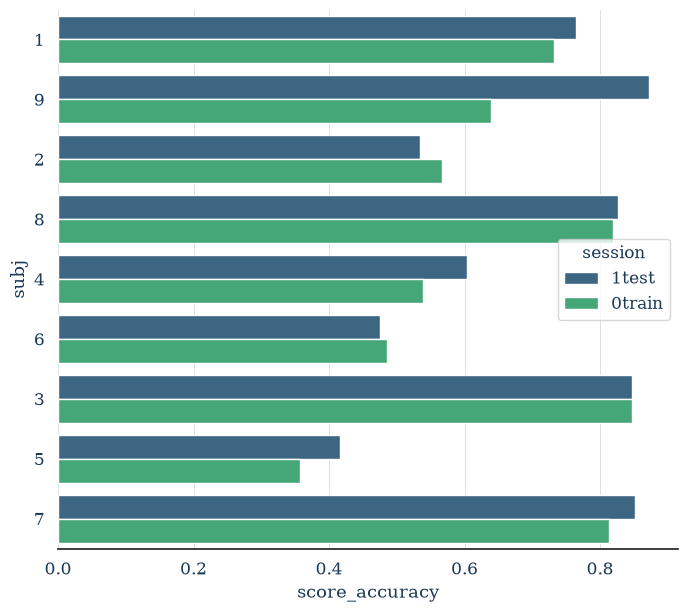

In [24]:
avgRes=[]
avgRes=pd.DataFrame(avgRes)
avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()
avgRes['Balanced Accuracy']=results.groupby('session')['score_balanced_accuracy'].mean()
avgRes['score_f1_macro']=results.groupby('session')['score_f1_macro'].mean()

print(avgRes)

fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()

## multiple tests

In [25]:

def frequency_mask(X, start_freq, band_width, sfreq=250):
    X = X.copy()

    stop_freq = start_freq + band_width

    sos = butter(
        N=4,
        Wn=[start_freq, stop_freq],
        btype="bandstop",
        fs=sfreq,
        output="sos"
    )

    X = sosfiltfilt(sos, X, axis=-1)

    return X

In [14]:
bandwidths=[4,6,8]

fmin=4
fmax=40
nums=3

In [28]:
accuracy=[]
freqs=[0,0,0]
for bw in bandwidths:
    all_avgs = []

    for i in range(nums):
        freqs[i]=np.random.uniform(fmin, fmax - bw)
    
    print(freqs)
    
    for freq in freqs:
            
        hider = FunctionTransformer(
            partial(
                frequency_mask,
                start_freq=freq,
                band_width=bw
            )
        )

        pipeline = make_pipeline(
            hider,
            CSP(n_components=8),
            LDA()
        )

        

        paradigm = mp.MotorImagery(
            scorer=["accuracy", "balanced_accuracy", "f1_macro"],
        )

        evaluation = WithinSessionEvaluation(
            paradigm=paradigm,
            datasets=[dataset],
            overwrite=True,
            hdf5_path=None
        )

        results = evaluation.process({"csp+lda": pipeline})
        
        avgRes=[]
        avgRes=pd.DataFrame(avgRes)
        avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()

        all_avgs.append(avgRes)
    
    TestAccuracy=0
    for dset in all_avgs:
        TestAccuracy+=dset.iloc[1]['Accuracy']
    accuracy.append(TestAccuracy/num)

Choosing from all possible events


[20.140159556098464, 18.58192328576406, 30.862416513906147]
Computing rank from data with rank=None
    Using tolerance 80 (2.2e-16 eps * 22 dim * 1.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 81 (2.2e-16 eps * 22 dim * 1.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with ra

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 40 (2.2e-16 eps * 22 dim * 8.3e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 40 (2.2e-16 eps * 22 dim * 8.3e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 40 (2.2e-16 eps * 22 dim * 8.3e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


...

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 84 (2.2e-16 eps * 22 dim * 1.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 82 (2.2e-16 eps * 22 dim * 1.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 82 (2.2e-16 eps * 22 dim * 1.7e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 44 (2.2e-16 eps * 22 dim * 9e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 44 (2.2e-16 eps * 22 dim * 9e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 44 (2.2e-16 eps * 22 dim * 9e+15  ma

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


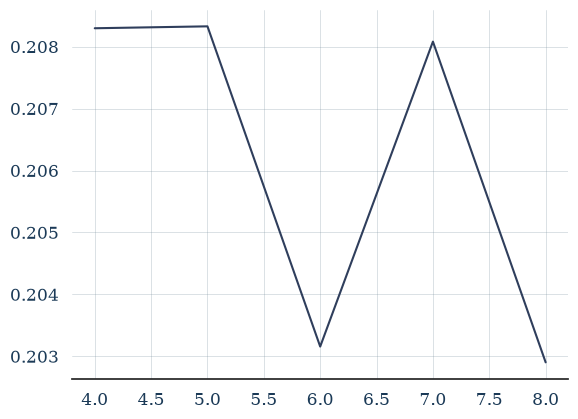

In [33]:
plt.plot(bandwidths, accuracy)

In [34]:
sum(accuracy)/len(accuracy)

np.float32(0.20615366)

## train only

In [15]:
import numpy as np
from scipy.signal import butter, sosfiltfilt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


class TrainOnlyFrequencyMaskClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        sfreq=250,
        f=4,
        band_width=4,
        n_components=8,
        random_state=None
    ):
        self.sfreq = sfreq
        self.f=f
        self.band_width=band_width
        self.n_components = n_components
        self.random_state = random_state

    def _frequency_mask(self, X):
        X = X.copy()

        band_width = self.band_width
        start_freq = self.f
        stop_freq = start_freq + band_width

        sos = butter(
            N=4,
            Wn=[start_freq, stop_freq],
            btype="bandstop",
            fs=self.sfreq,
            output="sos"
        )

        X = sosfiltfilt(sos, X, axis=-1)

        return X

    def fit(self, X, y):
        X_train_masked = self._frequency_mask(X)

        self.clf_ = make_pipeline(
            CSP(n_components=self.n_components),
            LDA()
        )

        self.clf_.fit(X_train_masked, y)
        return self

    def predict(self, X):
        return self.clf_.predict(X)

    def predict_proba(self, X):
        return self.clf_.predict_proba(X)

In [16]:
accuracy=[]
freqs=[0,0,0]

for bw in bandwidths:
    all_avgs = []

    for i in range(nums):
        freqs[i]=np.random.uniform(fmin, fmax - bw)
    
    print(freqs)
    
    for freq in freqs:
        
        
        pipeline = TrainOnlyFrequencyMaskClassifier(
            sfreq=250,
            f=freq,
            band_width=bw,
            n_components=8,
            random_state=42
        )

        evaluation = WithinSessionEvaluation(
            paradigm=paradigm,
            datasets=[dataset],
            overwrite=True,
            hdf5_path=None
        )

        results = evaluation.process({
            "csp+lda-trainFreqMaskOnly": pipeline
        })

        avgRes=[]
        avgRes=pd.DataFrame(avgRes)
        avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()

        all_avgs.append(avgRes)
    
    TestAccuracy=0
    for dset in all_avgs:
        TestAccuracy+=dset.iloc[1]['Accuracy']
    accuracy.append(TestAccuracy/nums)

[22.718506338466526, 5.387237116624959, 28.84025996158184]
Computing rank from data with rank=None
    Using tolerance 74 (2.2e-16 eps * 22 dim * 1.5e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 74 (2.2e-16 eps * 22 dim * 1.5e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with ran

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


Computing rank from data with rank=None
    Using tolerance 49 (2.2e-16 eps * 22 dim * 1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 49 (2.2e-16 eps * 22 dim * 1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 49 (2.2e-16 eps * 22 dim * 1e+16  ma

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


Computing rank from data with rank=None
    Using tolerance 85 (2.2e-16 eps * 22 dim * 1.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 86 (2.2e-16 eps * 22 dim * 1.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 84 (2.2e-16 eps * 22 dim * 1.7e+

...

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


Computing rank from data with rank=None
    Using tolerance 30 (2.2e-16 eps * 22 dim * 6.1e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 30 (2.2e-16 eps * 22 dim * 6.1e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 30 (2.2e-16 eps * 22 dim * 6.1e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


Computing rank from data with rank=None
    Using tolerance 40 (2.2e-16 eps * 22 dim * 8.1e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 39 (2.2e-16 eps * 22 dim * 8.1e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 39 (2.2e-16 eps * 22 dim * 8e+15

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


In [18]:
accuracy2=accuracy.copy()

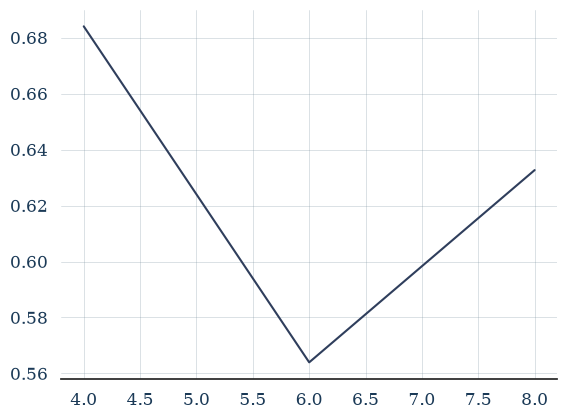

In [17]:
plt.plot(bandwidths, accuracy)

## test only

In [19]:
import numpy as np
from scipy.signal import butter, sosfiltfilt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


class TestOnlyFrequencyMaskClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        sfreq=250,
        f=4,
        band_width=4,
        n_components=8,
        random_state=None
    ):
        self.sfreq = sfreq
        self.f = f
        self.band_width = band_width
        self.n_components = n_components
        self.random_state = random_state

    def _frequency_mask(self, X):
        X = X.copy()

        start_freq = self.f
        stop_freq = start_freq + self.band_width

        sos = butter(
            N=4,
            Wn=[start_freq, stop_freq],
            btype="bandstop",
            fs=self.sfreq,
            output="sos"
        )

        return sosfiltfilt(sos, X, axis=-1)

    def fit(self, X, y):
        # Train on clean EEG
        self.clf_ = make_pipeline(
            CSP(n_components=self.n_components),
            LDA()
        )

        self.clf_.fit(X, y)
        return self

    def predict(self, X):
        X_test_masked = self._frequency_mask(X)
        return self.clf_.predict(X_test_masked)

    def predict_proba(self, X):
        X_test_masked = self._frequency_mask(X)
        return self.clf_.predict_proba(X_test_masked)

In [20]:
accuracy=[]
freqs=[0,0,0]

for bw in bandwidths:
    all_avgs = []

    for i in range(nums):
        freqs[i]=np.random.uniform(fmin, fmax - bw)
    
    print(freqs)
    
    for freq in freqs:
        
        
        pipeline = TestOnlyFrequencyMaskClassifier(
            sfreq=250,
            f=freq,
            band_width=bw,
            n_components=8,
            random_state=42
        )

        evaluation = WithinSessionEvaluation(
            paradigm=paradigm,
            datasets=[dataset],
            overwrite=True,
            hdf5_path=None
        )

        results = evaluation.process({
            "csp+lda-trainFreqMaskOnly": pipeline
        })

        avgRes=[]
        avgRes=pd.DataFrame(avgRes)
        avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()

        all_avgs.append(avgRes)
    
    TestAccuracy=0
    for dset in all_avgs:
        TestAccuracy+=dset.iloc[1]['Accuracy']
    accuracy.append(TestAccuracy/nums)

[28.765920594292865, 21.574291013364228, 19.355750953227226]
Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 22 dim * 7.7e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 22 dim * 7.8e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with r

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


Computing rank from data with rank=None
    Using tolerance 48 (2.2e-16 eps * 22 dim * 9.8e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 48 (2.2e-16 eps * 22 dim * 9.8e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 48 (2.2e-16 eps * 22 dim * 9.8e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


Computing rank from data with rank=None
    Using tolerance 43 (2.2e-16 eps * 22 dim * 8.7e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 42 (2.2e-16 eps * 22 dim * 8.6e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 42 (2.2e-16 eps * 22 dim * 8.6e+

...

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


Computing rank from data with rank=None
    Using tolerance 48 (2.2e-16 eps * 22 dim * 9.8e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 48 (2.2e-16 eps * 22 dim * 9.8e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 48 (2.2e-16 eps * 22 dim * 9.8e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


Computing rank from data with rank=None
    Using tolerance 80 (2.2e-16 eps * 22 dim * 1.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 81 (2.2e-16 eps * 22 dim * 1.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 80 (2.2e-16 eps * 22 dim * 1.6e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


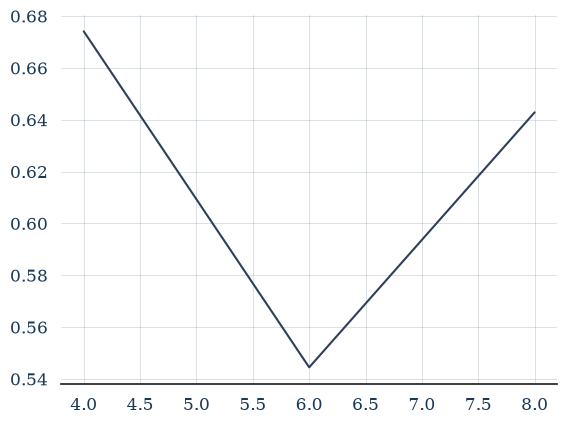

In [21]:
plt.plot(bandwidths, accuracy)